# 08. Одна модель со всеми признаками

Усреднение трёх моделей дало 0,725 на временной проверке. Но если объединить признаки в один CatBoost, можно обойтись одной моделью при расчёте ответов. Проверим два варианта: со всеми числовыми признаками и с добавленным `top_location`. Для сравнения возьмём сохранённые оценки ансамбля и уже проверенной модели с базой, маршрутами, контекстом, курсором и городом

In [1]:
# Открой ноутбук из корня проекта или из папки notebooks.
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "data" / "train.csv").is_file():
    raise FileNotFoundError("Не найдена папка data. Открой ноутбук из проекта.")
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from utils.features import build_features
from utils.journeys import build_journey_features
from utils.pointer_location import build_pointer_location_features
from utils.metric import precision_at_recall

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")

## Собираем единый набор

Включаем все группы из прошлых экспериментов: базовые события, ритм, маршруты, разнообразие объявлений, воронку, время между действиями и контекст просмотров. Добавляем `pointer_x_std`, `pointer_y_std`, `counter_zeros`. В варианте с городом `top_location` передаём CatBoost как категорию. Признаки User-Agent по-прежнему не используем

In [2]:
parse_dates = ["cookie_created_at", "window_start_ts", "window_end_ts"]
train = pd.read_csv("data/train.csv", parse_dates=parse_dates)
test = pd.read_csv("data/test.csv", parse_dates=parse_dates)
events = pd.read_csv("data/events.csv.gz", parse_dates=["event_ts"])

old_features, old_groups, n_inside = build_features(train, test, events)
journey_features, journey_groups = build_journey_features(train, test, events)
pointer_features = build_pointer_location_features(train, test, events)
features = old_features.merge(
    journey_features.drop(columns="split"), on="cookie_id", validate="one_to_one"
).merge(pointer_features, on="cookie_id", validate="one_to_one")
fit = features.iloc[:len(train)].reset_index(drop=True)
predict = features.iloc[len(train):].reset_index(drop=True)
y = train.target.to_numpy()
assert fit.cookie_id.equals(train.cookie_id)
assert predict.cookie_id.equals(test.cookie_id)

base = [column for column in old_groups["base"]
        if column not in {"headless_ua", "automation_ua", "ua_count"}]
mouse = ["pointer_x_std", "pointer_y_std", "counter_zeros"]
all_numeric = base.copy()
for name in ["rhythm", "routes", "breadth"]:
    all_numeric += old_groups[name]
for name in ["funnel", "timing", "context"]:
    all_numeric += journey_groups[name]
all_numeric += mouse
full_with_location = all_numeric + ["top_location"]
selected_context = (
    base + old_groups["routes"]
    + [column for column in journey_groups["context"]
       if column != "seller_switch_share"]
    + mouse + ["top_location"]
)
assert len(full_with_location) == len(set(full_with_location))
assert len(selected_context) == len(set(selected_context))
assert not set(full_with_location) & {"cookie_id", "target", "window_start_ts"}
print("Кук:", len(features), "| событий внутри окон:", n_inside)
print("Признаков в отобранной одиночной модели:", len(selected_context))
print("Числовых признаков в полной:", len(all_numeric), "| с городом:", len(full_with_location))

Кук: 16000 | событий внутри окон: 288126
Признаков в отобранной одиночной модели: 65
Числовых признаков в полной: 107 | с городом: 108


## Проверяем на будущих днях

Разбиение и настройки CatBoost оставляем прежними. На каждом отрезке модель обучается только на более ранних куках. Сравниваем по основной метрике: максимальный Precision при Recall не ниже 70%

In [3]:
folds = [
    ("11–13 апреля", "2026-04-11", "2026-04-14"),
    ("14–16 апреля", "2026-04-14", "2026-04-17"),
    ("17–19 апреля", "2026-04-17", "2026-04-20"),
]
configs = {"full_numeric": all_numeric, "full_with_location": full_with_location}


def make_model(with_location):
    return CatBoostClassifier(
        iterations=600, depth=6, learning_rate=.05, l2_leaf_reg=5,
        loss_function="Logloss", verbose=False, random_seed=RANDOM_STATE,
        thread_count=4, allow_writing_files=False,
        cat_features=["top_location"] if with_location else [],
    )

rows = []
predictions = []
importance = []
for name, columns in configs.items():
    for fold_name, start, end in folds:
        fit_mask = fit.window_start_ts.lt(start).to_numpy()
        valid_mask = fit.window_start_ts.ge(start).to_numpy() & fit.window_start_ts.lt(end).to_numpy()
        assert fit.loc[fit_mask, "window_start_ts"].max() < fit.loc[valid_mask, "window_start_ts"].min()
        model = make_model(name == "full_with_location")
        model.fit(fit.loc[fit_mask, columns], y[fit_mask])
        score = model.predict_proba(fit.loc[valid_mask, columns])[:, 1]
        rows.append({"model": name, "fold": fold_name,
                     "p_at_r70": precision_at_recall(y[valid_mask], score)})
        predictions.append(pd.DataFrame({
            "cookie_id": fit.loc[valid_mask, "cookie_id"].to_numpy(),
            "fold": fold_name, "target": y[valid_mask], "model": name,
            "score": score,
        }))
        if name == "full_with_location":
            importance.append(pd.Series(
                model.get_feature_importance(), index=columns, name=fold_name
            ))
    print("Проверено:", name)

results = pd.DataFrame(rows)
validation = pd.concat(predictions).pivot(
    index=["cookie_id", "fold", "target"], columns="model", values="score"
).reset_index()
summary = results.pivot(index="model", columns="fold", values="p_at_r70")
summary["среднее"] = summary.mean(axis=1)
display(summary[[name for name, _, _ in folds] + ["среднее"]].round(3))

Проверено: full_numeric


Проверено: full_with_location


fold,11–13 апреля,14–16 апреля,17–19 апреля,среднее
model,,,,
full_numeric,0.676,0.668,0.747,0.697
full_with_location,0.654,0.688,0.747,0.696


,11–13 апреля,14–16 апреля,17–19 апреля,среднее
вариант,,,,
Старый ансамбль,0.524,0.552,0.622,0.566
Один CatBoost: база + маршруты + контекст + новое,0.657,0.714,0.778,0.716
Три CatBoost с новыми признаками,0.680,0.688,0.806,0.725
Один CatBoost: все числовые,0.676,0.668,0.747,0.697
Один CatBoost: все признаки + город,0.654,0.688,0.747,0.696


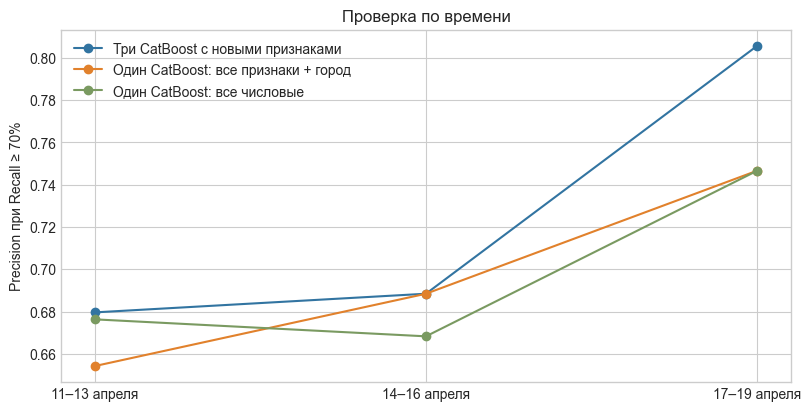

pointer_x_std               12.049
gap_under_30s                4.403
median_gap_sec               4.047
gap_p10_sec                  3.883
search_page_mean             3.759
categories                   2.824
multi_action_item_share      2.754
cookie_age_days              2.440
categories_per_item          2.214
locations                    2.105
items_per_event              2.020
counter_zeros                1.936
events_per_active_minute     1.917
same_event_next_share        1.476
pointer_x_unique             1.456
dtype: float64

Сохранены оценки: output/single_full_validation_scores.csv


In [4]:
keys = ["cookie_id", "fold", "target"]
previous = pd.read_csv("output/pointer_location_validation_scores.csv")
validation = validation.merge(
    previous[keys + ["context_plus", "base_plus", "routes_plus",
                     "catboost_no_ua", "routes", "context_pruned"]],
    on=keys, validate="one_to_one",
)
assert len(validation) == len(previous) == 6874
# Ранги пересчитываем из оценок моделей. Даже округление готового среднего
# до десяти знаков может поменять группы равных score около порога.
old_columns = ["catboost_no_ua", "routes", "context_pruned"]
new_columns = ["base_plus", "routes_plus", "context_plus"]
validation["old_rank_mean"] = validation.groupby("fold")[old_columns].rank(pct=True).mean(axis=1)
validation["new_rank_mean"] = validation.groupby("fold")[new_columns].rank(pct=True).mean(axis=1)
labels = {
    "old_rank_mean": "Старый ансамбль",
    "context_plus": "Один CatBoost: база + маршруты + контекст + новое",
    "new_rank_mean": "Три CatBoost с новыми признаками",
    "full_numeric": "Один CatBoost: все числовые",
    "full_with_location": "Один CatBoost: все признаки + город",
}
rows = []
for column, label in labels.items():
    row = {"вариант": label}
    for fold_name, part in validation.groupby("fold"):
        row[fold_name] = precision_at_recall(part.target, part[column])
    row["среднее"] = np.mean([row[name] for name, _, _ in folds])
    rows.append(row)
comparison = pd.DataFrame(rows).set_index("вариант")
display(comparison[[name for name, _, _ in folds] + ["среднее"]].round(3))

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
for name, color in [
    ("Три CatBoost с новыми признаками", "#3274A1"),
    ("Один CatBoost: все признаки + город", "#E1812C"),
    ("Один CatBoost: все числовые", "#7A9A61"),
]:
    ax.plot([f[0] for f in folds], comparison.loc[name, [f[0] for f in folds]],
            marker="o", label=name, color=color)
ax.set(ylabel="Precision при Recall ≥ 70%", title="Проверка по времени")
ax.legend()
plt.show()

importance_mean = pd.concat(importance, axis=1).mean(axis=1)
display(importance_mean.sort_values(ascending=False).head(15).round(3))

output = Path("output/single_full_validation_scores.csv")
validation.to_csv(output, index=False, float_format="%.17g")
print("Сохранены оценки:", output)

## Отдельные файлы с предсказаниями одной модели

Обучаем оба одиночных варианта на всём train. Отобранный вариант содержит базу, маршруты, контекст, курсор и город. Полный содержит ещё ритм, разнообразие и историю действий с объявлением. Сохраняем ответы отдельно, не перезаписывая текущий `output/submission.csv`

In [5]:
sample = pd.read_csv("data/sample_submission.csv")
for name, columns, path in [
    ("отобранная", selected_context, Path("output/single_context_submission.csv")),
    ("полная", full_with_location, Path("output/single_full_submission.csv")),
]:
    model = make_model(with_location=True)
    model.fit(fit[columns], y)
    score = model.predict_proba(predict[columns])[:, 1]
    answer = pd.DataFrame({"cookie_id": test.cookie_id, "score": score})
    assert answer.columns.tolist() == ["cookie_id", "score"]
    assert answer.cookie_id.equals(test.cookie_id)
    assert answer.cookie_id.is_unique
    assert set(answer.cookie_id) == set(sample.cookie_id)
    assert np.isfinite(answer.score).all() and answer.score.between(0, 1).all()
    answer.to_csv(path, index=False, float_format="%.10f")
    print(name, "модель:", path, "| кук:", len(answer))

отобранная модель: output/single_context_submission.csv | кук: 4909


полная модель: output/single_full_submission.csv | кук: 4909


## Вывод

Одна модель с отобранными признаками получила **0,657 / 0,714 / 0,778** по отрезкам, в среднем **0,716**. Полная версия со всеми 108 признаками и городом получила **0,654 / 0,688 / 0,747**, в среднем **0,696**. Полный числовой набор без города дал почти то же среднее, **0,697**.

Ансамбль трёх моделей с новыми признаками всё ещё впереди: **0,680 / 0,688 / 0,806**, в среднем **0,725**. Разница с отобранной одиночной моделью невелика, но полная одиночная модель уступила сильнее. Если важнее простота запуска, стоит рассмотреть отобранную одиночную модель: одна CatBoost вместо трёх, и для оценки куки не нужно ранжировать всю партию. Если цель именно метрика конкурса, пока лучше выглядит ансамбль. Небольшая валидация не гарантирует такого же порядка на скрытом test. На этом этапе ансамбль не заменяли. Позже проверим, помогут ли ему новые признаки и Word2Vec